In [1]:
# ----- Setup -----
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import random

# ----- Set experiment ID to test -----
exp_id = 7  # <- Change this value to test a different model  #-------

# ----- Load Metadata from Training -----
with open("results_metadata.json", "r") as f:
    metadata = pd.read_json(f)

row = metadata[metadata["experiment_id"] == exp_id].iloc[0]  #-------
PRED_LEN = int(row["pred_len"])  #-------

# ----- Load Zara 2 Data -----
df = pd.read_csv("converted_zara_1.csv")
x_mean, x_std = df['x'].mean(), df['x'].std()
y_mean, y_std = df['y'].mean(), df['y'].std()
df['x'] = (df['x'] - x_mean) / x_std
df['y'] = (df['y'] - y_mean) / y_std

SEQ_LEN = 8

# ----- Dataset Definition -----
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        obs, fut = self.trajectories[idx]
        return torch.tensor(obs, dtype=torch.float32), torch.tensor(fut, dtype=torch.float32)

# ----- Rebuild Zara 2 Trajectories -----
trajectories = []
for pid, person_df in df.groupby("person_id"):
    person_df = person_df.sort_values("frame_id")
    coords = person_df[['x', 'y']].values
    for i in range(len(coords) - SEQ_LEN - PRED_LEN):
        obs = coords[i:i+SEQ_LEN]
        fut = coords[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN]
        trajectories.append((obs, fut))

data_loader = DataLoader(TrajectoryDataset(trajectories), batch_size=64, shuffle=False)

# ----- LSTM Model Definition -----
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_len, num_layers, dropout, bidirectional):
        super(LSTMModel, self).__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional
        )
        direction_multiplier = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * direction_multiplier, 2 * output_len)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        hn = torch.cat((hn[-2], hn[-1]), dim=1) if self.bidirectional else hn[-1]
        out = self.fc(hn)
        return out.view(-1, self.fc.out_features // 2, 2)


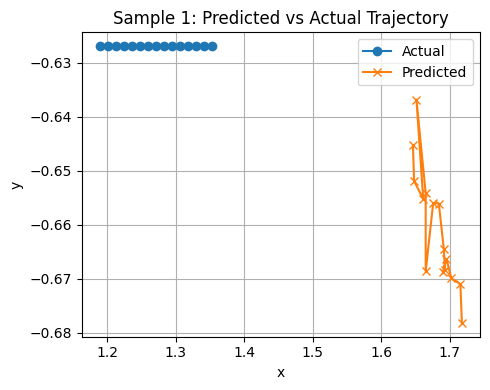

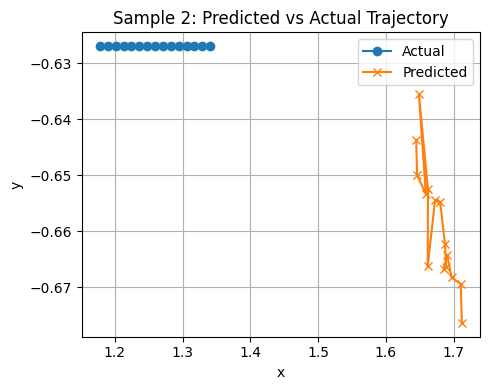

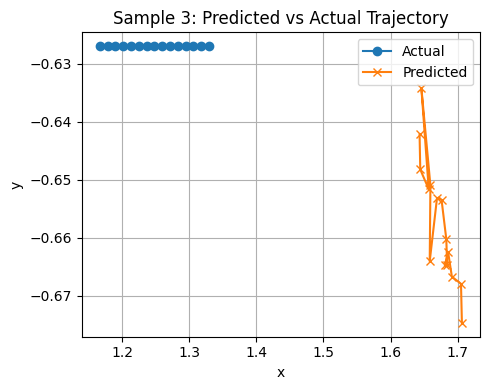

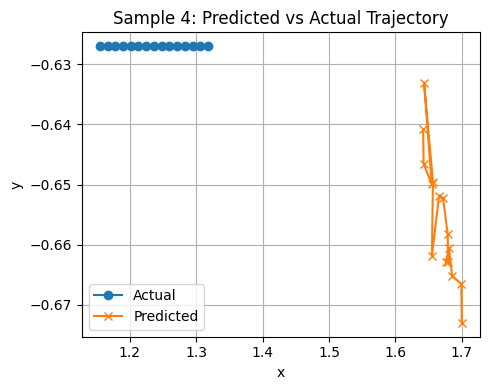

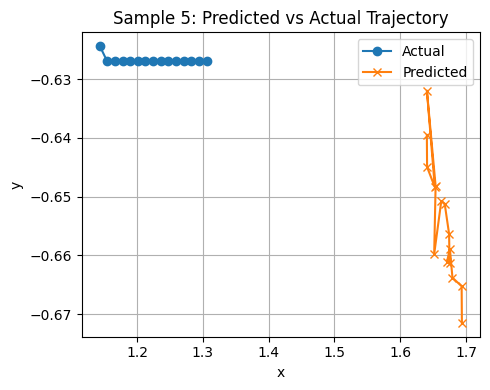

In [2]:
# ----- Evaluate Specific Model on Zara 2 -----
results = []
criterion = nn.MSELoss()

model_path = f"lstm_zara_exp_{exp_id}.pth"  #-------

if os.path.exists(model_path):  #-------
    model = LSTMModel(
        input_size=2,
        hidden_size=int(row["hidden_size"]),
        output_len=int(row["pred_len"]),
        num_layers=int(row["num_layers"]),
        dropout=float(row["dropout"]),
        bidirectional=bool(row["bidirectional"])
    )
    model.load_state_dict(torch.load(model_path))  #-------
    model.eval()

    total_loss = 0
    with torch.no_grad():
        for i, (obs, fut) in enumerate(data_loader):
            pred = model(obs)
            loss = criterion(pred, fut)
            total_loss += loss.item()

            # ----- Real-Time Predicted vs Actual Visualization -----  #-------
            if i == 0:  # visualize only the first batch for simplicity  #-------
                for j in range(min(5, obs.size(0))):  # show a few examples  #-------
                    actual = fut[j].numpy()
                    predicted = pred[j].numpy()
                    
                    plt.figure(figsize=(5, 4))
                    plt.plot(actual[:, 0], actual[:, 1], label='Actual', marker='o')
                    plt.plot(predicted[:, 0], predicted[:, 1], label='Predicted', marker='x')
                    plt.title(f"Sample {j+1}: Predicted vs Actual Trajectory")
                    plt.xlabel("x")
                    plt.ylabel("y")
                    plt.legend()
                    plt.grid(True)
                    plt.tight_layout()
                    plt.show()

    avg_loss = total_loss / len(data_loader)
    results.append({**row.to_dict(), "zara2_loss": avg_loss})  #-------
else:
    print(f"Model file {model_path} not found.")  #-------
